In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("../data/raw/housing.csv")

df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [5]:
df.shape
df.info()
df.describe()
df["SalePrice"].head()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

0    215000
1    105000
2    172000
3    244000
4    189900
Name: SalePrice, dtype: int64

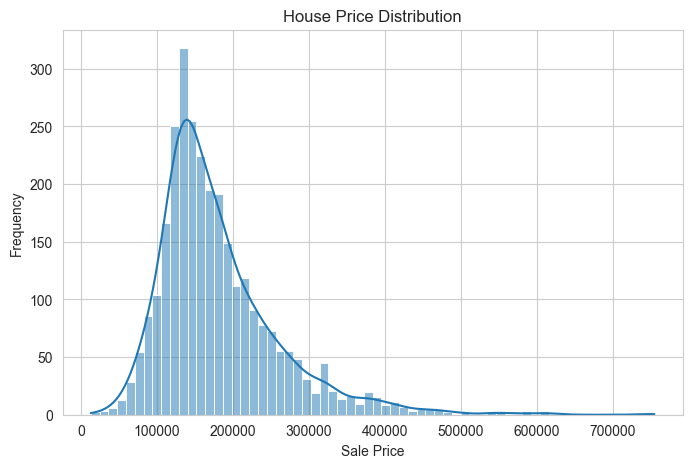

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice"], kde=True)

plt.title("House Price Distribution")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.show()

In [7]:
corr = df.corr(numeric_only=True)

corr["SalePrice"].sort_values(ascending=False)

SalePrice          1.000000
Overall Qual       0.799262
Gr Liv Area        0.706780
Garage Cars        0.647877
Garage Area        0.640401
Total Bsmt SF      0.632280
1st Flr SF         0.621676
Year Built         0.558426
Full Bath          0.545604
Year Remod/Add     0.532974
Garage Yr Blt      0.526965
Mas Vnr Area       0.508285
TotRms AbvGrd      0.495474
Fireplaces         0.474558
BsmtFin SF 1       0.432914
Lot Frontage       0.357318
Wood Deck SF       0.327143
Open Porch SF      0.312951
Half Bath          0.285056
Bsmt Full Bath     0.276050
2nd Flr SF         0.269373
Lot Area           0.266549
Bsmt Unf SF        0.182855
Bedroom AbvGr      0.143913
Screen Porch       0.112151
Pool Area          0.068403
Mo Sold            0.035259
3Ssn Porch         0.032225
BsmtFin SF 2       0.005891
Misc Val          -0.015691
Yr Sold           -0.030569
Order             -0.031408
Bsmt Half Bath    -0.035835
Low Qual Fin SF   -0.037660
MS SubClass       -0.085092
Overall Cond      -0

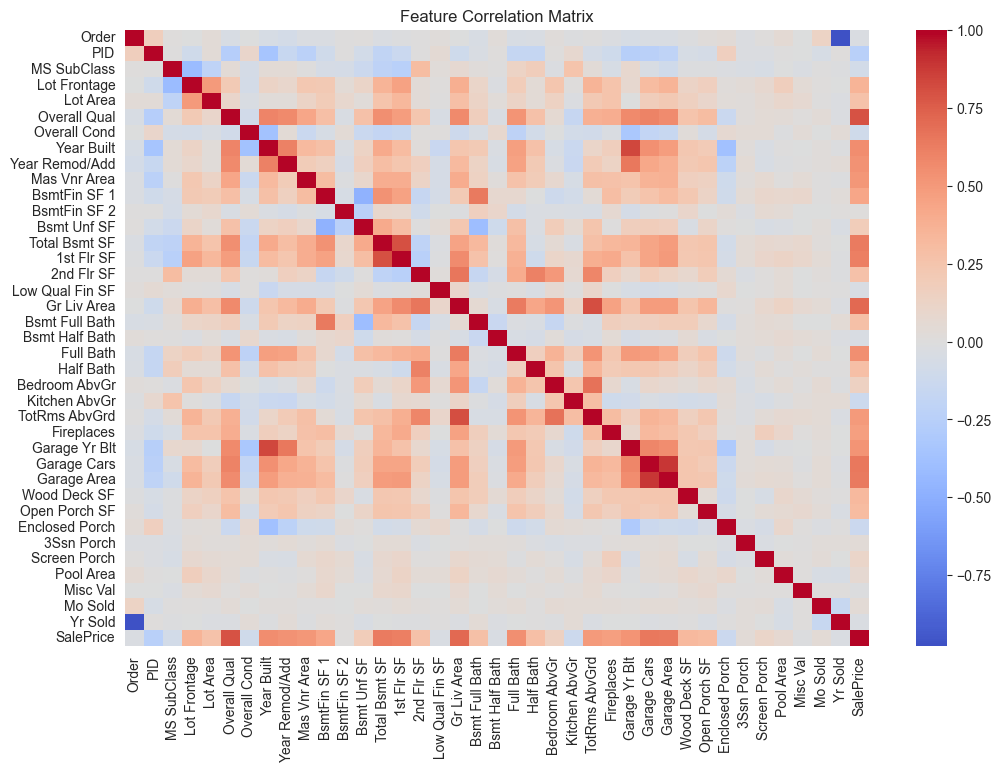

In [8]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            cmap="coolwarm",
            center=0)

plt.title("Feature Correlation Matrix")
plt.show()

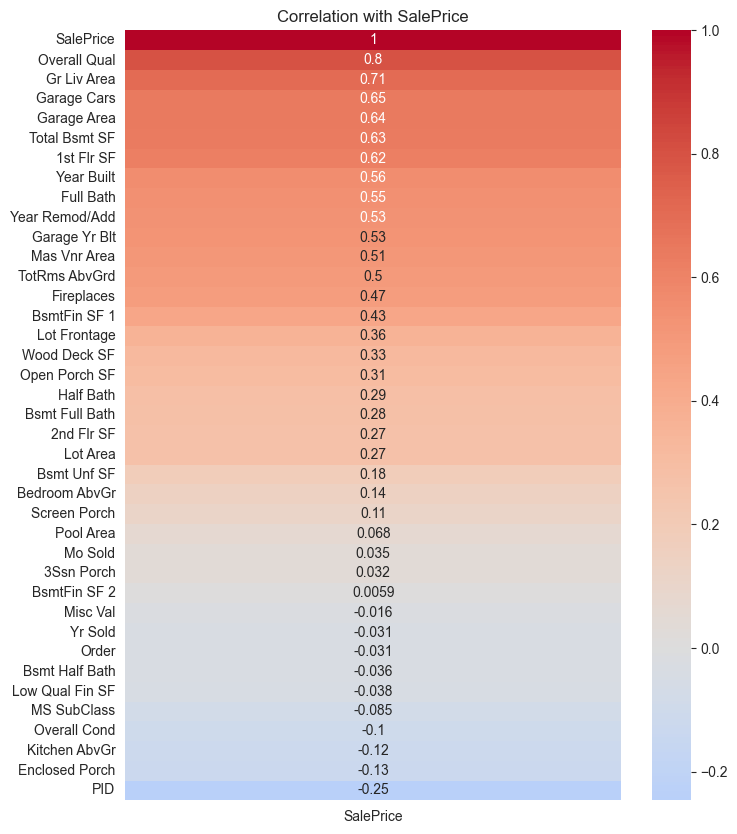

In [9]:
plt.figure(figsize=(8,10))

corr = df.corr(numeric_only=True)[["SalePrice"]].sort_values(by="SalePrice", ascending=False)

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            center=0)

plt.title("Correlation with SalePrice")
plt.show()

In [10]:
df.isnull().sum().sort_values(ascending=False).head(20)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Yr Blt      159
Garage Cond        159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
Bsmt Cond           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
dtype: int64

In [29]:
print("Missing values remaini              ng:", df.isnull().sum().sum())

Missing values remaining: 438


In [12]:
#to fiz the pool na
df["Pool QC"] = df["Pool QC"].fillna("NoPool")
df["Pool QC"].value_counts()

Pool QC
NoPool    2917
Ex           4
Gd           4
TA           3
Fa           2
Name: count, dtype: int64

In [15]:
df.columns

Index(['MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street',
       'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config',
       'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type',
       'House Style', 'Overall Qual', 'Overall Cond', 'Year Built',
       'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st',
       'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2',
       'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air',
       'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual',
       'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu',
       'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Gara

In [18]:
garage_cat_cols = ["Garage Type", "Garage Finish", "Garage Qual", "Garage Cond"]

for col in garage_cat_cols:
    df[col] = df[col].fillna("NoGarage")

df["Garage Yr Blt"] = df["Garage Yr Blt"].fillna(0)

In [20]:
missing_ratio = df.isnull().sum() / len(df)
missing_ratio.sort_values(ascending=False).head(10)

Misc Feature      0.963823
Alley             0.932423
Fence             0.804778
Mas Vnr Type      0.605802
Fireplace Qu      0.485324
Lot Frontage      0.167235
Bsmt Exposure     0.028328
BsmtFin Type 2    0.027645
Bsmt Cond         0.027304
BsmtFin Type 1    0.027304
dtype: float64

In [21]:
#droping the tables with high missing values
df = df.drop(columns=["Misc Feature", "Alley"])

In [22]:
#Encodng categorical missing values:
df["Fence"] = df["Fence"].fillna("NoFence")
df["Mas Vnr Type"] = df["Mas Vnr Type"].fillna("None")
df["Fireplace Qu"] = df["Fireplace Qu"].fillna("NoFireplace")

In [23]:
#Filling some number missing values
df["Lot Frontage"] = df["Lot Frontage"].fillna(df["Lot Frontage"].median())

In [25]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.shape

(2930, 264)

In [30]:
df_encoded.isnull().sum().sort_values(ascending=False).head(20)

Mas Vnr Area            23
Bsmt Full Bath           2
Bsmt Half Bath           2
BsmtFin SF 1             1
Garage Cars              1
Garage Area              1
BsmtFin SF 2             1
Bsmt Unf SF              1
Total Bsmt SF            1
Overall Cond             0
Year Built               0
Fence_MnWw               0
Garage Qual_Po           0
Garage Qual_TA           0
Garage Cond_Fa           0
Garage Cond_Gd           0
Garage Cond_NoGarage     0
Garage Cond_Po           0
Garage Cond_TA           0
Paved Drive_P            0
dtype: int64

In [31]:
# Fill numeric missing values with median
df_encoded = df_encoded.fillna(df_encoded.median())

In [32]:
df_encoded.isnull().sum().sum()

np.int64(0)

In [34]:
#saving the clean dataset
df_encoded.to_csv("../data/processed/housing_clean.csv", index=False)